# Comparativo 2020-2025 — Contagem por janela
Agrega resultados de `analise_2020.ipynb`...`analise_2025.ipynb` para ver evolução temporal do enquadramento de `internet`.


In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd()))
from config import TERMO_CENTRAL_REGEX, ABORDAGEM_A_TERMOS, ABORDAGEM_B_TERMOS, JANELA_TOKENS, MAPA_ARQUIVOS, ABORDAGEM_A_NOME, ABORDAGEM_B_NOME
from utils import extract_text, analisar_texto
import pandas as pd

PDF_DIR = Path("/workspaces/governanca-digital_mre/relatorios-gestao-mre")
rows=[]
for ano, pdf_file in sorted(MAPA_ARQUIVOS.items()):
    pdf = PDF_DIR / pdf_file
    txt = extract_text(pdf)
    res = analisar_texto(txt, TERMO_CENTRAL_REGEX, ABORDAGEM_A_TERMOS, ABORDAGEM_B_TERMOS, JANELA_TOKENS)
    total = res['total_A']+res['total_B']
    percA = res['total_A']/total*100 if total else 0
    percB = res['total_B']/total*100 if total else 0
    dom = ABORDAGEM_A_NOME if res['total_A']>res['total_B'] else ABORDAGEM_B_NOME if res['total_B']>res['total_A'] else "Empate"
    rows.append({"ano":ano, "ocorrencias":res['n_ocorrencias'], f"total_{ABORDAGEM_A_NOME}":res['total_A'], f"total_{ABORDAGEM_B_NOME}":res['total_B'], "%A": round(percA,1), "%B": round(percB,1), "dominante": dom, "cnt_A":res['cnt_A'], "cnt_B":res['cnt_B']})
    print(f"{ano}: occ={res['n_ocorrencias']} A={res['total_A']} B={res['total_B']} dom={dom}")
df = pd.DataFrame(rows)
display(df.style.set_caption("Comparativo 2020-2025 — entorno de 'internet'").hide(axis='index'))


2020: occ=8 A=7 B=3 dom=Soberana/Multilateral
2021: occ=3 A=0 B=3 dom=Mercado/Inovação
MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

2022: occ=19 A=23 B=8 dom=Soberana/Multilateral
2023: occ=4 A=1 B=0 dom=Soberana/Multilateral
2024: occ=3 A=1 B=0 dom=Soberana/Multilateral
2025: occ=0 A=0 B=0 dom=Empate


ano,ocorrencias,total_Soberana/Multilateral,total_Mercado/Inovação,%A,%B,dominante,cnt_A,cnt_B
2020,8,7,3,70.000000,30.000000,Soberana/Multilateral,"{'multilateral': 1, 'governanca': 6}","{'inovacao': 2, 'desenvolvimento': 1}"
2021,3,0,3,0.000000,100.000000,Mercado/Inovação,{},{'desenvolvimento': 3}
2022,19,23,8,74.200000,25.800000,Soberana/Multilateral,"{'multissetorial': 4, 'governanca': 16, 'multissetoriais': 2, 'multilateral': 1}","{'desenvolvimento': 7, 'inovacao': 1}"
2023,4,1,0,100.000000,0.000000,Soberana/Multilateral,{'governanca': 1},{}
2024,3,1,0,100.000000,0.000000,Soberana/Multilateral,{'multilaterais': 1},{}
2025,0,0,0,0.000000,0.000000,Empate,{},{}


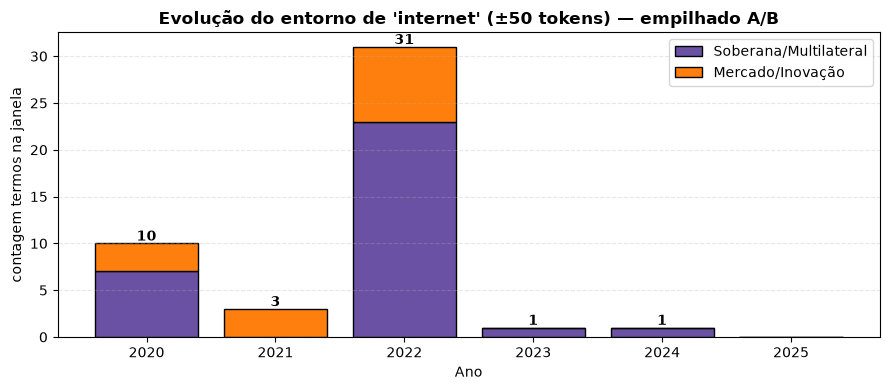

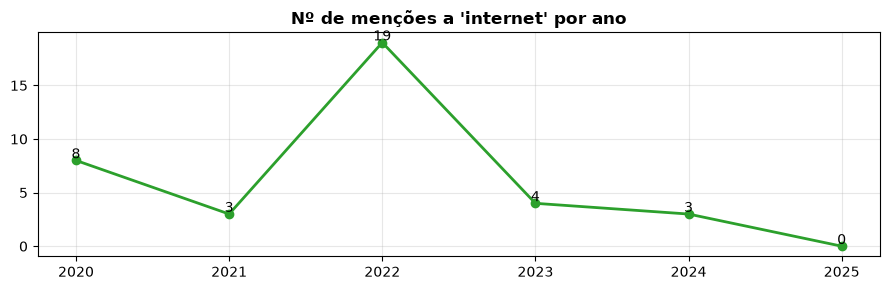

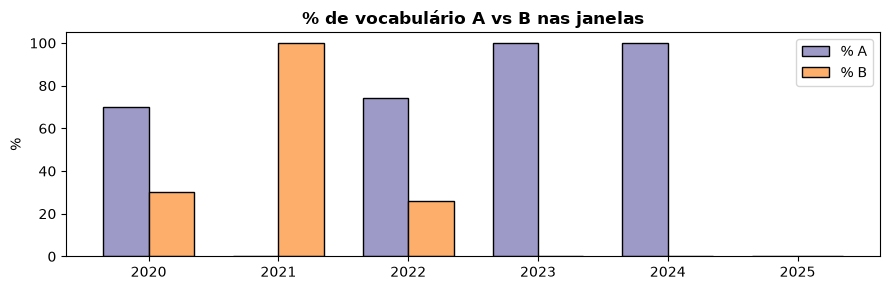

In [2]:
import matplotlib.pyplot as plt
import numpy as np
# --- Gráfico empilhado A/B por ano ---
fig, ax = plt.subplots(figsize=(9,4))
anos = df['ano']
a_vals = df[f"total_{ABORDAGEM_A_NOME}"]
b_vals = df[f"total_{ABORDAGEM_B_NOME}"]
ax.bar(anos, a_vals, label=ABORDAGEM_A_NOME, color='#6a51a3', edgecolor='black')
ax.bar(anos, b_vals, bottom=a_vals, label=ABORDAGEM_B_NOME, color='#ff7f0e', edgecolor='black')
for i, (a,b) in enumerate(zip(a_vals, b_vals)):
    tot=a+b
    if tot>0:
        ax.text(anos.iloc[i], tot+0.3, str(tot), ha='center', fontweight='bold')
ax.set_xticks(anos)
ax.set_xlabel("Ano")
ax.set_ylabel("contagem termos na janela")
ax.set_title("Evolução do entorno de 'internet' (±50 tokens) — empilhado A/B", fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Linha ocorrências ---
plt.figure(figsize=(9,3))
plt.plot(df['ano'], df['ocorrencias'], marker='o', linewidth=2, color='#2ca02c')
for x,y in zip(df['ano'], df['ocorrencias']):
    plt.text(x, y+0.2, str(y), ha='center')
plt.title("Nº de menções a 'internet' por ano", fontweight='bold')
plt.xticks(df['ano'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Barras % A vs % B ---
plt.figure(figsize=(9,3))
x=np.arange(len(df))
w=0.35
plt.bar(x-w/2, df['%A'], width=w, label='% A', color='#9e9ac8', edgecolor='black')
plt.bar(x+w/2, df['%B'], width=w, label='% B', color='#fdae6b', edgecolor='black')
plt.xticks(x, df['ano'])
plt.ylabel("%")
plt.title("% de vocabulário A vs B nas janelas", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
# Salvar comparativo
df.to_csv("comparativo_contagem.csv", index=False)
print("Salvo comparativo_contagem.csv")
df.to_json("comparativo_contagem.json", orient="records", indent=2, force_ascii=False)
print("Salvo comparativo_contagem.json")
display(df)


Salvo comparativo_contagem.csv
Salvo comparativo_contagem.json


,ano,ocorrencias,total_Soberana/Multilateral,total_Mercado/Inovação,%A,%B,dominante,cnt_A,cnt_B
0,2020,8,7,3,70.0,30.0,Soberana/Multilateral,"{'multilateral': 1, 'governanca': 6}","{'inovacao': 2, 'desenvolvimento': 1}"
1,2021,3,0,3,0.0,100.0,Mercado/Inovação,{},{'desenvolvimento': 3}
2,2022,19,23,8,74.2,25.8,Soberana/Multilateral,"{'multissetorial': 4, 'governanca': 16, 'multi...","{'desenvolvimento': 7, 'inovacao': 1}"
3,2023,4,1,0,100.0,0.0,Soberana/Multilateral,{'governanca': 1},{}
4,2024,3,1,0,100.0,0.0,Soberana/Multilateral,{'multilaterais': 1},{}
5,2025,0,0,0,0.0,0.0,Empate,{},{}
